# Stage 3 — Exploratory Data Analysis

Cleaned hourly weather data for ~10 cities across 3 years.

**Goal of this notebook:** quickly get a feel for the data — seasonality,
differences between cities, and basic trends — before we push it to Spark
and train a model.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = (10, 4)

df = pd.read_csv('../data/clean/weather_clean.csv', parse_dates=['time'])
print(df.shape)
df.head()

(263040, 19)


,time,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,rain,snowfall,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,city,latitude,longitude,year,month,day,hour,day_of_year
0,2022-01-01 00:00:00+00:00,3.0,97.0,2.6,0.0,0.0,0.0,1008.5,99.0,9.0,247.0,Bucharest,44.4268,26.1025,2022,1,1,0,1
1,2022-01-01 01:00:00+00:00,3.0,97.0,2.5,0.0,0.0,0.0,1008.2,81.0,8.1,249.0,Bucharest,44.4268,26.1025,2022,1,1,1,1
2,2022-01-01 02:00:00+00:00,2.5,97.0,2.0,0.0,0.0,0.0,1008.1,64.0,6.8,270.0,Bucharest,44.4268,26.1025,2022,1,1,2,1
3,2022-01-01 03:00:00+00:00,1.5,98.0,1.1,0.0,0.0,0.0,1007.4,99.0,8.7,246.0,Bucharest,44.4268,26.1025,2022,1,1,3,1
4,2022-01-01 04:00:00+00:00,1.7,98.0,1.4,0.0,0.0,0.0,1007.5,100.0,7.6,262.0,Bucharest,44.4268,26.1025,2022,1,1,4,1


In [3]:
# Sanity check — how much data per city?
df['city'].value_counts()

city
Bucharest      26304
Sibiu          26304
Cluj-Napoca    26304
Berlin         26304
Paris          26304
Madrid         26304
Rome           26304
London         26304
New York       26304
Tokyo          26304
Name: count, dtype: int64

In [4]:
# Summary stats — gives us a feel for ranges, sanity, missingness.
df.describe()

,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,rain,snowfall,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,latitude,longitude,year,month,day,hour,day_of_year
count,263040.000000,263040.000000,263040.000000,263040.000000,263040.000000,263040.000000,263040.000000,263040.000000,263040.000000,263040.000000,263040.000000,263040.000000,263040.000000,263040.000000,263040.000000,263040.0000,263040.000000
mean,13.424016,71.658257,7.618559,0.098976,0.095503,0.002434,996.180818,58.004870,11.483051,185.033101,44.858870,16.391820,2023.000912,6.521898,15.732664,11.5000,183.166971
std,8.860999,19.433392,7.359258,0.532026,0.528307,0.039543,25.251325,42.388695,7.080972,102.415779,5.035711,49.465999,0.816684,3.448993,8.801387,6.9222,105.462982
min,-17.200000,5.000000,-27.500000,0.000000,0.000000,0.000000,912.600000,0.000000,0.000000,0.000000,35.676200,-74.006000,2022.000000,1.000000,1.000000,0.0000,1.000000
25%,6.800000,58.000000,2.700000,0.000000,0.000000,0.000000,977.800000,9.000000,6.300000,94.000000,40.712800,-0.127600,2022.000000,4.000000,8.000000,5.7500,92.000000
50%,13.100000,76.000000,7.900000,0.000000,0.000000,0.000000,1006.200000,73.000000,9.800000,196.000000,45.112550,12.950700,2023.000000,7.000000,16.000000,11.5000,183.000000
75%,19.800000,88.000000,12.900000,0.000000,0.000000,0.000000,1013.700000,100.000000,15.300000,268.000000,48.856600,24.125600,2024.000000,10.000000,23.000000,17.2500,274.250000
max,41.300000,100.000000,27.000000,26.900000,26.900000,2.870000,1045.000000,100.000000,76.000000,360.000000,52.520000,139.650300,2024.000000,12.000000,31.000000,23.0000,366.000000


## 1) Seasonality — average temperature per month, per city

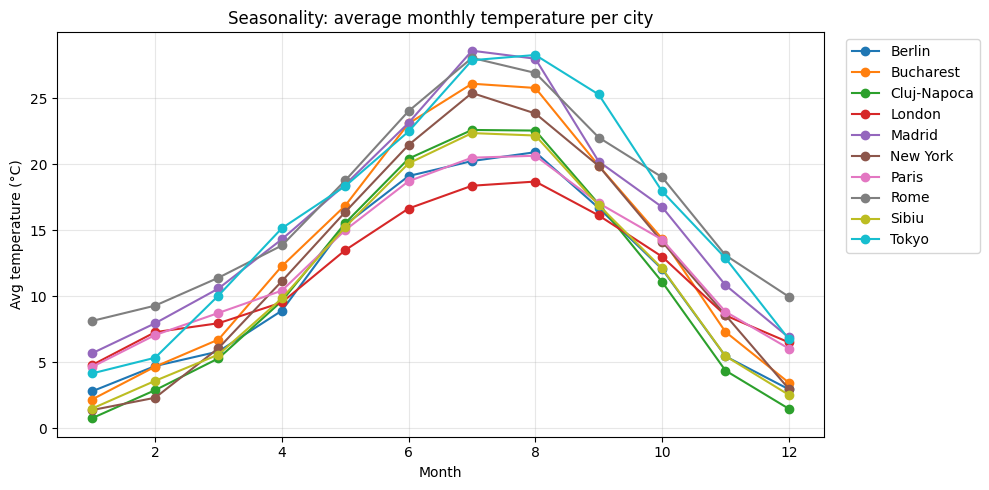

In [5]:
monthly = (df.groupby(['city', 'month'])['temperature_2m']
             .mean().reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
for city, g in monthly.groupby('city'):
    ax.plot(g['month'], g['temperature_2m'], marker='o', label=city)
ax.set_xlabel('Month'); ax.set_ylabel('Avg temperature (°C)')
ax.set_title('Seasonality: average monthly temperature per city')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Insight:** Clear sine-wave shape in every Northern-Hemisphere city — coldest
around Jan/Feb, warmest in Jul/Aug. Mediterranean cities (Madrid, Rome) sit
above the others almost every month.

## 2) City comparison — yearly average temperature

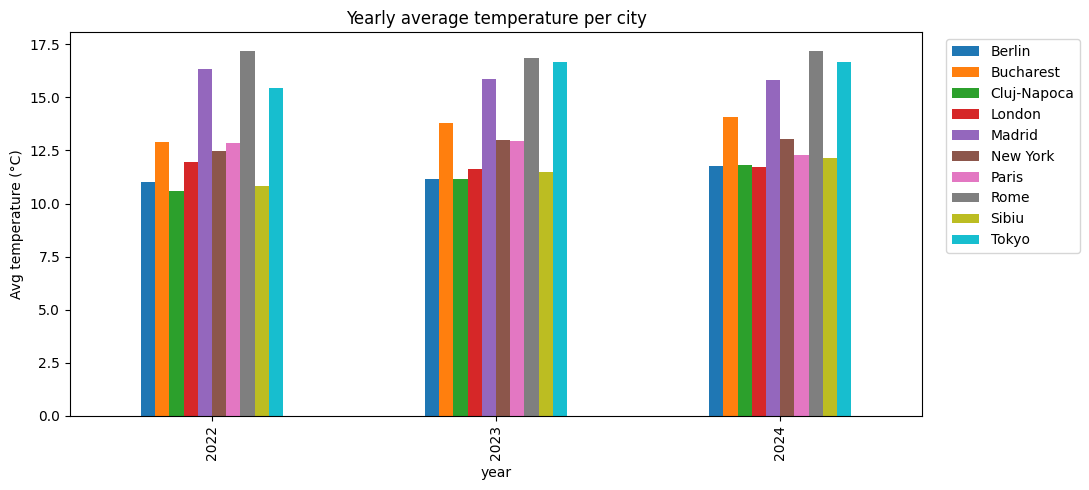

In [6]:
yearly = df.groupby(['city', 'year'])['temperature_2m'].mean().reset_index()
yearly.pivot(index='year', columns='city', values='temperature_2m').plot(
    kind='bar', figsize=(11, 5)
)
plt.ylabel('Avg temperature (°C)')
plt.title('Yearly average temperature per city')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

**Insight:** Year-to-year variation is small (~1°C) but the *ranking*
of cities is stable — useful for the model: city is a strong baseline feature.

## 3) Trend — rolling 30-day mean for one city

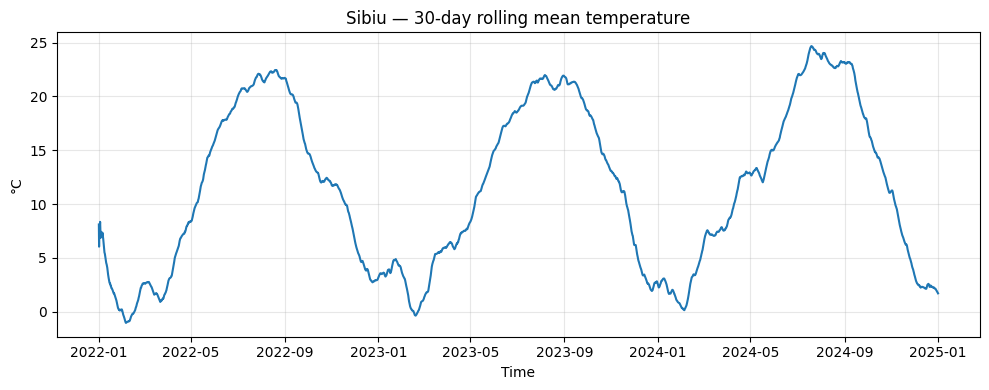

In [7]:
one = df[df['city'] == 'Sibiu'].sort_values('time').copy()
one['temp_30d'] = one['temperature_2m'].rolling(24*30, min_periods=1).mean()

plt.plot(one['time'], one['temp_30d'])
plt.title('Sibiu — 30-day rolling mean temperature')
plt.ylabel('°C'); plt.xlabel('Time'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Insight:** Smooth seasonal cycle; if peaks creep upward year-over-year that
would point to a warming trend. With only 3 years of data we can *see* it but
shouldn't make strong claims.

## 4) Correlations between numeric features

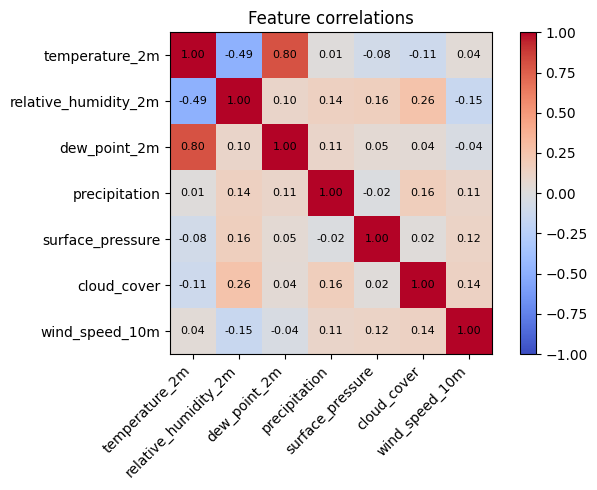

In [8]:
num_cols = ['temperature_2m','relative_humidity_2m','dew_point_2m',
            'precipitation','surface_pressure','cloud_cover',
            'wind_speed_10m']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im); plt.title('Feature correlations'); plt.tight_layout(); plt.show()

**Insight:** dew point correlates very strongly with temperature (expected by
physics); humidity correlates negatively. These will be the strongest features
for our regression model in stage 5.

## Summary
* Strong seasonality + stable per-city offsets.
* Dew point + humidity are the most temperature-predictive features.
* Data is clean enough to push into Spark for scale aggregations next.